In [1]:
# 03. Baseline Model Training
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
from preprocessing import build_dataset, VOCAB, CHAR_TO_IDX
from baseline import PeptideDataset, Encoder, Decoder, BaselineModel

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
print(f"Using device: {device}")


/Users/akshaymohanrevankar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-v0nk5nf3 because there was an issue with the default path (/Users/akshaymohanrevankar/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/akshaymohanrevankar/.cache/fontconfig
	/Users/akshaymohanrevankar/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/akshaymohanrevankar/.cache/fontconfig
	/Users/akshaymohanrevankar/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/akshaymohanrevankar/.cache/fontconfig
	/Users/akshaymohanrevankar/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/akshaymohanrevankar/.cache/fontconfig
	/Users/akshaymohanrevankar/.fontconfig


Matplotlib is building the font cache; this may take a moment.


Using device: mps


In [2]:
# 1. Load Data
xlsx_path = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Database search output_Ecoli_EV_1.xlsx"
mzml_path = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Ecoli_EV_1.mzML"

print("Building dataset... (This extracts and preprocesses up to 2000 spectra)")
X, y = build_dataset(mzml_path, xlsx_path, max_spectra=2000)
print(f"Dataset shape: X={X.shape}, y={y.shape}")


Building dataset... (This extracts and preprocesses up to 2000 spectra)


Dataset shape: X=(1488, 20000), y=(1488, 32)


In [3]:
# 2. Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}  Val size: {len(X_val)}  Test size: {len(X_test)}")

batch_size = 32
train_loader = DataLoader(PeptideDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PeptideDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(PeptideDataset(X_test, y_test), batch_size=batch_size)


Train size: 1041  Val size: 223  Test size: 224


In [4]:
# 3. Model Initialization
encoder = Encoder(input_dim=20000, context_dim=256)
decoder = Decoder(vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256)
model = BaselineModel(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1) # ignore PAD token
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

print(model)


BaselineModel(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=20000, out_features=1024, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
      (6): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): Decoder(
    (embedding): Embedding(23, 64, padding_idx=0)
    (rnn): LSTM(320, 256, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=23, bias=True)
  )
)


In [5]:
# 4. Training Loop
epochs = 10
train_losses = []
val_losses = []
val_aa_recalls = []

def calc_aa_recall(preds, targets):
    pred_classes = preds.argmax(dim=-1)
    mask = targets != 0
    correct = (pred_classes == targets) & mask
    if mask.sum().item() == 0:
        return 0.0
    return correct.sum().item() / mask.sum().item()

best_val_loss = float('inf')
os.makedirs('../checkpoints', exist_ok=True)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        
        optimizer.zero_grad()
        
        trg_input = trg[:, :-1]
        trg_target = trg[:, 1:]
        
        output = model(src, trg_input)
        
        output_flat = output.reshape(-1, output.shape[-1])
        trg_target_flat = trg_target.reshape(-1)
        
        loss = criterion(output_flat, trg_target_flat)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        
    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0
    aa_recall_sum = 0
    
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            trg_input = trg[:, :-1]
            trg_target = trg[:, 1:]
            
            output = model(src, trg_input)
            
            loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
            val_loss += loss.item()
            
            aa_recall_sum += calc_aa_recall(output, trg_target)
            
    val_loss /= len(val_loader)
    val_aa_recall = aa_recall_sum / len(val_loader)
    
    val_losses.append(val_loss)
    val_aa_recalls.append(val_aa_recall)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AA Recall: {val_aa_recall:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        try:
            torch.save(model.state_dict(), '../checkpoints/baseline_best.pt')
        except Exception:
            pass

print("Training Complete!")


2026-03-28 20:30:26.548 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_26-845631680‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:26.609 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_26-723071543‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:26.668 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_26-1629814769‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:30:26.980 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_26-4176522408‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:26.984 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_26-2122988148‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:30:27.503 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_27-2898813283‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:27.583 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_27-279426416‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:27.644 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_27-3289202156‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:30:28.305 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_28-3610214496‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:30:28.661 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_28-4018612849‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:30:28.664 Python[53446:3299609] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-53446-2026-03-28_20_30_28-1703464446‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


...

Epoch 6/10 | Train Loss: 2.5670 | Val Loss: 2.6452 | Val AA Recall: 0.2151


Epoch 7/10 | Train Loss: 2.5370 | Val Loss: 2.6416 | Val AA Recall: 0.2167


Epoch 8/10 | Train Loss: 2.4898 | Val Loss: 2.6244 | Val AA Recall: 0.2299


Epoch 9/10 | Train Loss: 2.4315 | Val Loss: 2.5999 | Val AA Recall: 0.2461


Epoch 10/10 | Train Loss: 2.3760 | Val Loss: 2.5639 | Val AA Recall: 0.2747
Training Complete!


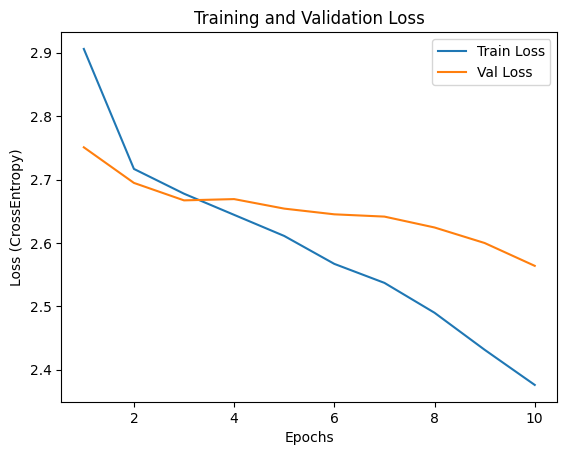

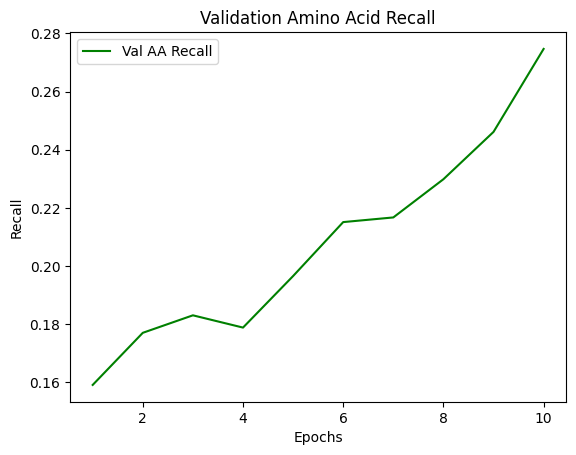

In [6]:
# 5. Plot Learning Curves
plt.figure()
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig('../figures/eda/training_loss.png')
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), val_aa_recalls, color='g', label='Val AA Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Validation Amino Acid Recall')
plt.legend()
plt.show()


In [7]:
# 6. Evaluation and Examples
try:
    model.load_state_dict(torch.load('../checkpoints/baseline_best.pt'))
except:
    pass
model.eval()

IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR[0] = ''
IDX_TO_CHAR[1] = '<SOS>'
IDX_TO_CHAR[2] = '<EOS>'

def decode_sequence(tokens):
    return "".join([IDX_TO_CHAR.get(t.item(), "") for t in tokens if t.item() not in [0, 1, 2]])

print("--- 3 Example Predictions ---")
with torch.no_grad():
    for i, (src, trg) in enumerate(test_loader):
        src, trg = src.to(device), trg.to(device)
        trg_input = trg[:, :-1]
        
        output = model(src, trg_input)
        preds = output.argmax(dim=-1)
        
        for j in range(3):
            if j >= len(preds): break
            pred_seq = decode_sequence(preds[j])
            true_seq = decode_sequence(trg[j, 1:])
            print(f"Ground Truth: {true_seq}")
            print(f"Predicted   : {pred_seq}")
            print("-" * 50)
        break


--- 3 Example Predictions ---
Ground Truth: AVAAGMNPMDLK
Predicted   : VLLQIFVFKKKKRRRRRRRRRRRRRRRRR
--------------------------------------------------
Ground Truth: MIQEQTMLNVADNSGAR
Predicted   : GVDLLLPPDAEENTLVYKKKKKKKKKKKK
--------------------------------------------------
Ground Truth: DDEVIVLTGK
Predicted   : GLLLLLYYYYKKKKKKKKKKKKKKKKKKK
--------------------------------------------------
